In [34]:
import pandas as pd

# Load dataset
df = pd.read_csv(r"C:\Users\user\OneDrive\Documents\Education\Masters\Semester\Semester 2\Agile Data Science\PMA\bank-additional-full.csv", sep=";")

# Preview dataset
print(df.head())

# Dataset summary
print(df.info())


   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

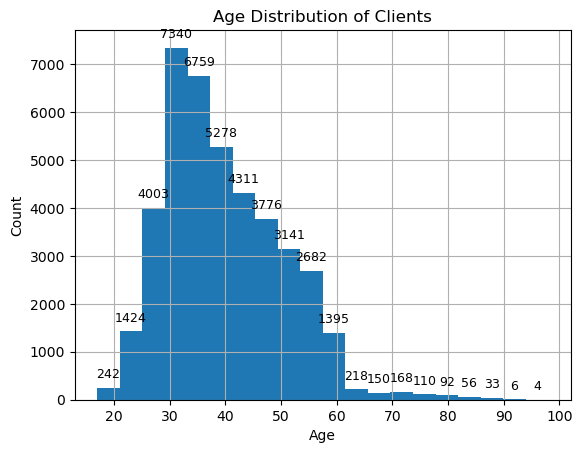

In [19]:
import matplotlib.pyplot as plt

# Create histogram
ax = df['age'].hist(bins=20)
plt.title("Age Distribution of Clients")
plt.xlabel("Age")
plt.ylabel("Count")

# Add data labels on top of each bar
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),                      # count value
        (p.get_x() + p.get_width() / 2., p.get_height()),  # position
        ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
        textcoords='offset points'
    )

plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_12268\233901949.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='y', y='duration', data=df, palette="Set2")


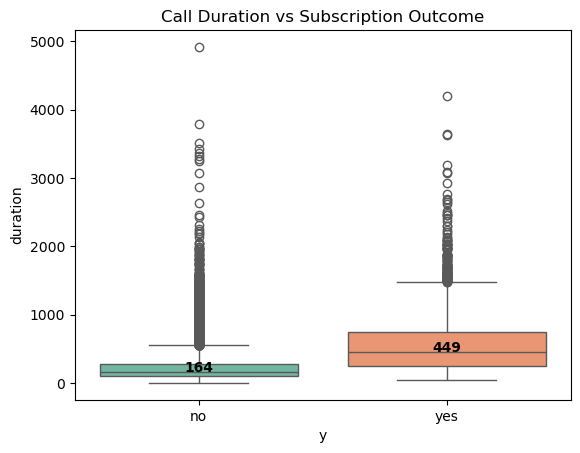

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create the boxplot
ax = sns.boxplot(x='y', y='duration', data=df, palette="Set2")
plt.title("Call Duration vs Subscription Outcome")

# Add median labels for each category
medians = df.groupby('y')['duration'].median()
for i, median in enumerate(medians):
    ax.text(i, median, f'{median:.0f}', 
            horizontalalignment='center', 
            color='black', weight='bold')

plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_12268\3639863039.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


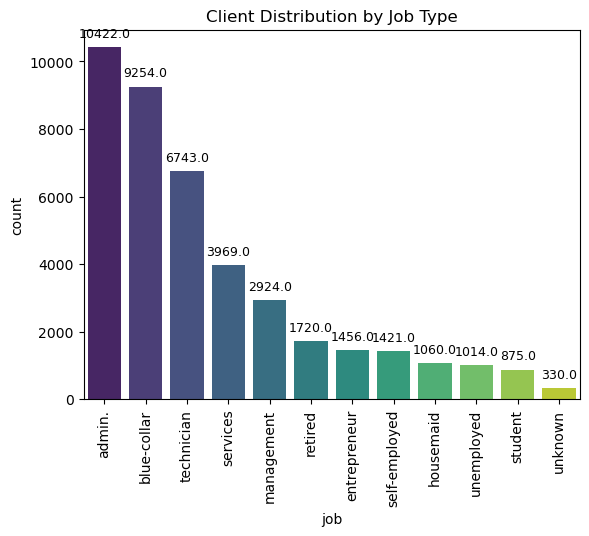

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the countplot
ax = sns.countplot(
    x='job',
    data=df,
    order=df['job'].value_counts().index,
    palette="viridis"
)

# Rotate x-axis labels for readability
plt.xticks(rotation=90)
plt.title("Client Distribution by Job Type")

# Add data labels on top of each bar
for p in ax.patches:
    ax.annotate(
        str(p.get_height()),                          
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
        textcoords='offset points'
    )

plt.show()


In [25]:
# Check for missing values
df.isnull().sum()



age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [26]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Check value counts for each categorical column
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())


Column: job
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

Column: marital
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

Column: education
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

Column: default
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

Column: housing
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

Column: loan
loan
no         33950
yes         6248
unknown      9

In [27]:
# Check for duplicate rows
df.duplicated().sum()


12

In [28]:
# Quick check for extreme values in numerical columns
df[['age','duration','campaign','pdays','previous']].describe()


,age,duration,campaign,pdays,previous
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963
std,10.42125,259.279249,2.770014,186.910907,0.494901
min,17.00000,0.000000,1.000000,0.000000,0.000000
25%,32.00000,102.000000,1.000000,999.000000,0.000000
50%,38.00000,180.000000,2.000000,999.000000,0.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000
max,98.00000,4918.000000,56.000000,999.000000,7.000000


In [35]:
import numpy as np
import pandas as pd

# 1. Handle missing categorical values ("unknown")
df.replace('unknown', np.nan, inplace=True)

# Check missing values
print("Missing values per column:\n", df.isnull().sum())

# 2. Remove duplicate records
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates().copy()   # force copy to avoid warnings
print("Duplicates after:", df.duplicated().sum())

# 3. Handle special code in 'pdays'
# Create a flag for previous contact
df.loc[:, 'pdays_flag'] = df['pdays'].apply(lambda x: 1 if x != 999 else 0)

# Replace 999 with NaN (optional, if treating as missing)
df.loc[:, 'pdays'] = df['pdays'].replace(999, "no previous contact")

# 4. Define function to remove outliers using IQR
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)].copy()

# Remove outliers in key variables
df = remove_outliers_iqr(df, 'duration')
df = remove_outliers_iqr(df, 'campaign')
df = remove_outliers_iqr(df, 'age')

# 5. Final check
print(df.info())
print(df.describe(include='all'))


Missing values per column:
 age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64
Duplicates before: 12
Duplicates after: 0


C:\Users\user\AppData\Local\Temp\ipykernel_12268\886095625.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['no previous contact' 'no previous contact' 'no previous contact' ...
 'no previous contact' 'no previous contact' 'no previous contact']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, 'pdays'] = df['pdays'].replace(999, "no previous contact")


<class 'pandas.core.frame.DataFrame'>
Index: 35524 entries, 0 to 41186
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             35524 non-null  int64  
 1   job             35245 non-null  object 
 2   marital         35462 non-null  object 
 3   education       34066 non-null  object 
 4   default         28154 non-null  object 
 5   housing         34667 non-null  object 
 6   loan            34667 non-null  object 
 7   contact         35524 non-null  object 
 8   month           35524 non-null  object 
 9   day_of_week     35524 non-null  object 
 10  duration        35524 non-null  int64  
 11  campaign        35524 non-null  int64  
 12  pdays           35524 non-null  object 
 13  previous        35524 non-null  int64  
 14  poutcome        35524 non-null  object 
 15  emp.var.rate    35524 non-null  float64
 16  cons.price.idx  35524 non-null  float64
 17  cons.conf.idx   35524 non-null  floa

In [36]:
# Drop rows with missing values (strict cleaning)
df = df.dropna(subset=['job','marital','education','default','housing','loan'])

print("Missing values per column:\n", df.isnull().sum())

print(df.info())
print(df.describe(include='all'))

Missing values per column:
 age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
pdays_flag        0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 26371 entries, 0 to 41186
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             26371 non-null  int64  
 1   job             26371 non-null  object 
 2   marital         26371 non-null  object 
 3   education       26371 non-null  object 
 4   default         26371 non-null  object 
 5   housing         26371 non-null  object 
 6   loan            26371 non-null  object 
 7   conta

In [37]:
import pandas as pd

# Identify all string (object) variables automatically
string_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical variables:", string_cols)

# Apply one-hot encoding to all categorical variables
df_encoded = pd.get_dummies(df, columns=string_cols, drop_first=True)

# Encode target variable 'y' separately (binary: yes=1, no=0)
df_encoded['y'] = df['y'].map({'yes':1, 'no':0})

print(df_encoded.head())
print("Shape after encoding:", df_encoded.shape)


Categorical variables: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'pdays', 'poutcome', 'y']
   age  duration  campaign  previous  emp.var.rate  cons.price.idx  \
0   56       261         1         0           1.1          93.994   
2   37       226         1         0           1.1          93.994   
3   40       151         1         0           1.1          93.994   
4   56       307         1         0           1.1          93.994   
6   59       139         1         0           1.1          93.994   

   cons.conf.idx  euribor3m  nr.employed  pdays_flag  ...  pdays_21  pdays_22  \
0          -36.4      4.857       5191.0           0  ...     False     False   
2          -36.4      4.857       5191.0           0  ...     False     False   
3          -36.4      4.857       5191.0           0  ...     False     False   
4          -36.4      4.857       5191.0           0  ...     False     False   
6          -36.4      4.857 

In [38]:
from sklearn.preprocessing import StandardScaler

# Identify numeric columns automatically
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
print("Numeric variables:", numeric_cols)

# Initialize scaler
scaler = StandardScaler()

# Apply scaling
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

# Check results
print(df_encoded[numeric_cols].describe())


Numeric variables: ['age', 'duration', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'pdays_flag']
                age      duration      campaign      previous  emp.var.rate  \
count  2.637100e+04  2.637100e+04  2.637100e+04  2.637100e+04  2.637100e+04   
mean  -1.131652e-16  6.897688e-17  4.311055e-17  1.724422e-17  1.207095e-16   
std    1.000019e+00  1.000019e+00  1.000019e+00  1.000019e+00  1.000019e+00   
min   -2.272173e+00 -1.480081e+00 -8.061653e-01 -3.774770e-01 -2.060730e+00   
25%   -7.982507e-01 -7.522432e-01 -8.061653e-01 -3.774770e-01 -1.064166e+00   
50%   -2.718497e-01 -2.598823e-01 -2.162824e-02 -3.774770e-01  7.421066e-01   
75%    6.756720e-01  5.250408e-01  7.629088e-01 -3.774770e-01  9.289624e-01   
max    3.202397e+00  3.115287e+00  3.116520e+00  1.298420e+01  9.289624e-01   

       cons.price.idx  cons.conf.idx     euribor3m   nr.employed    pdays_flag  
count    2.637100e+04   2.637100e+04  2.637100e+04 

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Separate features and target
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

# Train-test split (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Initialize baseline Logistic Regression model
log_reg = LogisticRegression(max_iter=1000)

# Train the model
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0
Confusion Matrix:
 [[7160    0]
 [   0  752]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      7160
           1       1.00      1.00      1.00       752

    accuracy                           1.00      7912
   macro avg       1.00      1.00      1.00      7912
weighted avg       1.00      1.00      1.00      7912



In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

# Feature importance
importances = rf_model.feature_importances_
feature_names = X_train.columns
feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
print(feat_imp.sort_values(by='Importance', ascending=False).head(10))


Accuracy: 1.0
Confusion Matrix:
 [[7160    0]
 [   0  752]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      7160
           1       1.00      1.00      1.00       752

    accuracy                           1.00      7912
   macro avg       1.00      1.00      1.00      7912
weighted avg       1.00      1.00      1.00      7912

                      Feature  Importance
72                      y_yes    0.620236
7                   euribor3m    0.059583
1                    duration    0.056492
8                 nr.employed    0.038262
9                  pdays_flag    0.024198
4                emp.var.rate    0.022006
5              cons.price.idx    0.020355
69  pdays_no previous contact    0.019748
6               cons.conf.idx    0.018559
0                         age    0.016702


In [41]:
# Automated validation script

# 1. Check missing values
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
pdays_flag        0
dtype: int64
